SVMs were run on the PubMed repo in order to assess how many more entries could be added to the Info Portals

In [3]:
import joblib
import pandas as pd
from tqdm import tqdm

# Load model and vectorizer
vectorizer, model = joblib.load("Models/svm_250k_title_abstract.joblib")

# Parameters
input_file = "H:/Datasets/pubmed_full.csv"
output_file = "Samples/pubmed_svm_class1_predictions.csv"
chunksize = 100_000
estimated_total_rows = 38_000_000

# Prepare output file
header_written = False

# Read and classify in chunks with progress bar
with pd.read_csv(input_file, chunksize=chunksize) as reader:
    for chunk in tqdm(reader, total=estimated_total_rows // chunksize + 1, desc="Classifying PubMed"):
        # Combine title and abstract
        chunk["text"] = chunk["title"].fillna("") + " " + chunk["abstract"].fillna("")

        # Vectorize
        X = vectorizer.transform(chunk["text"])

        # Predict
        probs = model.predict_proba(X)[:, 1]
        preds = (probs >= 0.5).astype(int)

        # Add predictions to chunk
        chunk["svm_pred_prob"] = probs
        chunk["svm_pred_label"] = preds

        # Filter to positive class
        df_positive = chunk[chunk["svm_pred_label"] == 1].drop(columns=["text"])

        # Write to output
        if not df_positive.empty:
            df_positive.to_csv(output_file, mode='a', index=False, header=not header_written)
            header_written = True

print(f"✅ Classification complete. Saved class 1 rows to {output_file}")


Classifying PubMed:  14%|█▍        | 55/381 [10:14<15:07,  2.79s/it]  c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\tqdm\std.py:1181: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for obj in iterable:
Classifying PubMed:  15%|█▍        | 56/381 [10:16<14:43,  2.72s/it]c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\tqdm\std.py:1181: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for obj in iterable:
Classifying PubMed:  36%|███▌      | 136/381 [28:57<14:15,  3.49s/it]  c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\tqdm\std.py:1181: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for obj in iterable:
Classifying PubMed:  38%|███▊      | 144/381 [29:46<38:25,  9.73s/it]c:\Users\user1\anaconda3\envs\RAGLLMs\Lib\site-packages\tqdm\std.py:1181: DtypeWarning: Columns (9) have mixed types. Specify dtype

✅ Classification complete. Saved class 1 rows to Samples/pubmed_svm_class1_predictions.csv


Inclusion classification of all of pubmed with SVMs took 97 minutes

In [4]:
df_p = pd.read_csv("Samples/pubmed_svm_class1_predictions.csv")
df_p

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_34392\2031959644.py:1: DtypeWarning: Columns (0,5,6,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p = pd.read_csv("Samples/pubmed_svm_class1_predictions.csv")


,pmid,title,abstract,authors,language,year,month,publication_type,country,agency,mesh_terms,doi,svm_pred_prob,svm_pred_label
0,2804,[Sorption method of water regeneration for cos...,The paper describes sanitary-hygienic and tech...,V A Gaĭdadymov; A G Prishchep; K V Zarubina; L...,rus,1976,4,Journal Article,Russia (Federation),NaN,Adsorption; Anti-Bacterial Agents; Detergents;...,NaN,0.5470662396878377,1
1,3424,Elevated serum and hepatic tyrosine aminotrans...,NaN,H H Stibbs; J R Seed,eng,1976,5,"Journal Article; Research Support, U.S. Gov't,...",United States,NaN,Animals; Arvicolinae; Blood; Liver; Phenylpyru...,10.1016/0014-4894(76)90003-5,0.7362604647945697,1
2,3855,Vector control of filariasis in the Solomon Is...,"In Solomon Islands, filariasis is caused by th...",R H Webber,eng,1976,6,Journal Article,Thailand,NaN,"Adolescent; Adult; Aged; Anopheles; Child, Pre...",NaN,0.5392922874953555,1
3,5682,Elimination of aziridine residues from chemost...,NaN,V P Sharma,eng,1976,8,Journal Article,England,NaN,Animals; Aziridines; Azirines; Culicidae; Hydr...,10.1038/261135a0,0.560408639341503,1
4,5822,Implication of rifampicin-quinone in the irrev...,1. When [3H]rifampicin is incubated with rat l...,H M Bolt; H Remmer,eng,1976,8,Journal Article,England,NaN,Animals; Binding Sites; DNA; Kinetics; Liver; ...,10.3109/00498257609151608,0.5545273177744658,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188299,38122554,Lepra in Italy.,NaN,NaN,eng,0,0,Journal Article,United States,NaN,NaN,PMC10325505,0.934378,1
188300,38122566,On Diseases of the Eye.,NaN,Velpeau,eng,0,0,Journal Article,United States,NaN,NaN,PMC10325518,0.689654,1
188301,38123120,Leishmania donovani mevalonate kinase regulate...,Despite the well-established role of macrophag...,Tanvir Bamra; Taj Shafi; Sushmita Das; Manjay ...,eng,2024,5,Journal Article,France,NaN,Leishmania donovani; Phagocytosis; Actins; Mac...,S0300-9084(23)00326-7,0.651837,1
188302,38123249,Large language models: a new chapter in digita...,NaN,The Lancet Digital Health,eng,2023,12,Editorial,England,NaN,Digital Health; Language,S2589-7500(23)00254-6,0.792749,1


In [20]:
df_fin['pmid'].duplicated().sum()

np.int64(535)

In [21]:
df_fin[df_fin['pmid'].duplicated()]

,pmid,title,abstract,authors,language,year,month,publication_type,country,agency,...,Snakebite envenoming_prob,Snakebite envenoming_pred,Soil-transmitted helminths_prob,Soil-transmitted helminths_pred,Trachoma_prob,Trachoma_pred,Yaws_prob,Yaws_pred,Zika virus_prob,Zika virus_pred
382,2804,[Sorption method of water regeneration for cos...,The paper describes sanitary-hygienic and tech...,V A Gaĭdadymov; A G Prishchep; K V Zarubina; L...,rus,1976,4,Journal Article,Russia (Federation),NaN,...,0.033266,0,0.042971,0,0.024771,0,0.001672,0,0.001872,0
383,3424,Elevated serum and hepatic tyrosine aminotrans...,NaN,H H Stibbs; J R Seed,eng,1976,5,"Journal Article; Research Support, U.S. Gov't,...",United States,NaN,...,0.000031,0,0.000988,0,0.001020,0,0.000232,0,0.000193,0
384,3855,Vector control of filariasis in the Solomon Is...,"In Solomon Islands, filariasis is caused by th...",R H Webber,eng,1976,6,Journal Article,Thailand,NaN,...,0.000121,0,0.017247,0,0.001486,0,0.006796,0,0.001714,0
385,5682,Elimination of aziridine residues from chemost...,NaN,V P Sharma,eng,1976,8,Journal Article,England,NaN,...,0.015643,0,0.006815,0,0.004462,0,0.000328,0,0.073648,0
386,5822,Implication of rifampicin-quinone in the irrev...,1. When [3H]rifampicin is incubated with rat l...,H M Bolt; H Remmer,eng,1976,8,Journal Article,England,NaN,...,0.229370,0,0.013237,0,0.001178,0,0.000545,0,0.001702,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180964,36874576,Characterising and Addressing the Psychosocial...,<b>Background:</b> Tuberculosis (TB)-related ...,Ahmad Fuady; Agus Fitriangga; Agus Sugiharto; ...,eng,0,0,Journal Article,England,Wellcome Trust; Medical Research Council,...,0.001264,0,0.026359,0,0.011363,0,0.000815,0,0.006553,0
181053,36636741,Rapid molecular assays for the detection of th...,The pantropic emergence of severe dengue disea...,Madeeha Ahmed; Nina M Pollak; Leon E Hugo; And...,eng,0,0,Journal Article,United States,NaN,...,0.000165,0,0.003895,0,0.001530,0,0.000563,0,0.991417,1
181638,36969719,Perceptions about controlled human infection m...,<b>Introduction:</b> Controlled Human Infecti...,Abhishek Sharma; Aditi Apte; Medha Rajappa; Ma...,eng,0,0,Journal Article,England,NaN,...,0.001555,0,0.009586,0,0.008123,0,0.001865,0,0.050521,0
183715,37007907,Practical considerations for a TB controlled h...,<b>Background:</b> Tuberculosis (TB) remains ...,Stephen B Gordon; Simon Sichone; Anthony E Chi...,eng,0,0,Systematic Review; Journal Article,England,Wellcome Trust; Wellcome Trust; Medical Resear...,...,0.000882,0,0.026185,0,0.013578,0,0.001803,0,0.004818,0


In [5]:
import joblib
import pandas as pd
from tqdm import tqdm

# Load vectorizer, model, and disease label list
model_path = "Models/Disease_Classification/combined_OvR_SVM_TFIDF_calibrated.joblib"
vectorizer, model, disease_cols = joblib.load(model_path)

# Input: previously filtered SVM class 1 entries
input_file = "Samples/pubmed_svm_class1_predictions.csv"
output_file = "Samples/pubmed_svm_class1_diseases.csv"

chunksize = 10_000
estimated_rows = 188_300 # Estimate if unknown — tqdm uses this for ETA

# Header control
header_written = False

with pd.read_csv(input_file, chunksize=chunksize) as reader:
    for chunk in tqdm(reader, total=estimated_rows // chunksize + 1, desc="Classifying diseases"):
        # Build text (title + abstract)
        chunk["text"] = chunk["title"].fillna("") + " " + chunk["abstract"].fillna("")

        # Vectorize
        X = vectorizer.transform(chunk["text"])

        # Predict
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)

        # Add disease columns
        for i, lab in enumerate(disease_cols):
            chunk[f"{lab}_prob"] = y_prob[:, i]
            chunk[f"{lab}_pred"] = y_pred[:, i]

        # Drop helper column
        chunk = chunk.drop(columns=["text"])

        # Write with append
        chunk.to_csv(output_file, mode='a', index=False, header=not header_written)
        header_written = True

print(f"✅ Done! Saved disease predictions to {output_file}")


Classifying diseases: 100%|██████████| 19/19 [00:53<00:00,  2.82s/it]

✅ Done! Saved disease predictions to Samples/pubmed_svm_class1_diseases.csv


In [6]:
df_fin = pd.read_csv('Samples/pubmed_svm_class1_diseases.csv')
df_fin

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_34392\1096133411.py:1: DtypeWarning: Columns (0,5,6,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fin = pd.read_csv('Samples/pubmed_svm_class1_diseases.csv')


,pmid,title,abstract,authors,language,year,month,publication_type,country,agency,...,Snakebite envenoming_prob,Snakebite envenoming_pred,Soil-transmitted helminths_prob,Soil-transmitted helminths_pred,Trachoma_prob,Trachoma_pred,Yaws_prob,Yaws_pred,Zika virus_prob,Zika virus_pred
0,2804,[Sorption method of water regeneration for cos...,The paper describes sanitary-hygienic and tech...,V A Gaĭdadymov; A G Prishchep; K V Zarubina; L...,rus,1976,4,Journal Article,Russia (Federation),NaN,...,0.033266,0,0.042971,0,0.024771,0,0.001672,0,0.001872,0
1,3424,Elevated serum and hepatic tyrosine aminotrans...,NaN,H H Stibbs; J R Seed,eng,1976,5,"Journal Article; Research Support, U.S. Gov't,...",United States,NaN,...,0.000031,0,0.000988,0,0.001020,0,0.000232,0,0.000193,0
2,3855,Vector control of filariasis in the Solomon Is...,"In Solomon Islands, filariasis is caused by th...",R H Webber,eng,1976,6,Journal Article,Thailand,NaN,...,0.000121,0,0.017247,0,0.001486,0,0.006796,0,0.001714,0
3,5682,Elimination of aziridine residues from chemost...,NaN,V P Sharma,eng,1976,8,Journal Article,England,NaN,...,0.015643,0,0.006815,0,0.004462,0,0.000328,0,0.073648,0
4,5822,Implication of rifampicin-quinone in the irrev...,1. When [3H]rifampicin is incubated with rat l...,H M Bolt; H Remmer,eng,1976,8,Journal Article,England,NaN,...,0.229370,0,0.013237,0,0.001178,0,0.000545,0,0.001702,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188299,38122554,Lepra in Italy.,NaN,NaN,eng,0,0,Journal Article,United States,NaN,...,0.003528,0,0.008946,0,0.003401,0,0.000235,0,0.001255,0
188300,38122566,On Diseases of the Eye.,NaN,Velpeau,eng,0,0,Journal Article,United States,NaN,...,0.000499,0,0.011416,0,0.999147,1,0.019713,0,0.008057,0
188301,38123120,Leishmania donovani mevalonate kinase regulate...,Despite the well-established role of macrophag...,Tanvir Bamra; Taj Shafi; Sushmita Das; Manjay ...,eng,2024,5,Journal Article,France,NaN,...,0.000381,0,0.001352,0,0.000685,0,0.000222,0,0.001373,0
188302,38123249,Large language models: a new chapter in digita...,NaN,The Lancet Digital Health,eng,2023,12,Editorial,England,NaN,...,0.013006,0,0.022213,0,0.005654,0,0.089460,0,0.042192,0


In [13]:
import pandas as pd
from tqdm import tqdm

# ───────────── Load datasets ─────────────
df_pred = pd.read_csv("Samples/pubmed_svm_class1_diseases.csv", low_memory=False)
df_ntd = pd.read_csv("Datasets/publicationsDatasetInfoPortals.csv", low_memory=False)

# ───────────── DOI Match ─────────────
doi_set = set(df_ntd["bibcite_doi"].dropna().astype(str))
df_pred["doi"] = df_pred["doi"].astype(str)
df_doi_matches = df_pred[df_pred["doi"].isin(doi_set)].copy()

# ───────────── Title Normalization ─────────────
def normalize_title(s):
    return (
        s.astype(str)
         .str.lower()
         .str.replace(r"\W+", " ", regex=True)
         .str.strip()
    )

df_ntd = df_ntd.dropna(subset=["bibcite_title"]).copy()
df_pred = df_pred.dropna(subset=["title"]).copy()

df_ntd["norm_title_ntd"] = normalize_title(df_ntd["bibcite_title"])
df_pred["norm_title_pred"] = normalize_title(df_pred["title"])

title_set = set(df_ntd["norm_title_ntd"])
df_title_matches = df_pred[df_pred["norm_title_pred"].isin(title_set)].copy()

# ───────────── Combine Matches (Union) ─────────────
df_matches = pd.concat([df_doi_matches, df_title_matches], ignore_index=True)
df_matches = df_matches.drop_duplicates(subset=["doi", "title"])

print(f"✅ Matched {len(df_matches):,} PubMed prediction entries to Info Platforms")

# ───────────── Optional: Save matched entries ─────────────
df_matches.to_csv("Samples/pubmed_predictions_matched_to_InfoPlatforms.csv", index=False)
print("💾 Saved matched prediction entries to Samples/pubmed_predictions_matched_to_InfoPlatforms.csv")


✅ Matched 26,751 PubMed prediction entries to Info Platforms
💾 Saved matched prediction entries to Samples/pubmed_predictions_matched_to_InfoPlatforms.csv


In [22]:
df_matches[df_matches['pmid'].duplicated()]

,pmid,title,abstract,authors,language,year,month,publication_type,country,agency,...,Snakebite envenoming_pred,Soil-transmitted helminths_prob,Soil-transmitted helminths_pred,Trachoma_prob,Trachoma_pred,Yaws_prob,Yaws_pred,Zika virus_prob,Zika virus_pred,norm_title_pred
6412,32399199,Burden and risk factors for snakebite in India...,<b>Introduction:</b> Snakebite is a neglected...,Soumyadeep Bhaumik; Robyn Norton; Jagnoor Jagnoor,eng,2020,10,"Journal Article; Research Support, Non-U.S. Gov't",England,NaN,...,1,0.021968,0,0.015906,0,0.002630,0,0.001490,0,NaN
23408,24358891,Reprogramming diminishes retention of Mycobact...,Bacterial pathogens can manipulate or subvert ...,Toshihiro Masaki; Aidan McGlinchey; Simon R To...,eng,2013,12,Journal Article,England,Wellcome Trust; NIAID NIH HHS; NINDS NIH HHS,...,0,0.004425,0,0.003045,0,0.000177,0,0.001349,0,reprogramming diminishes retention of mycobact...
23473,24358891,Reprogramming diminishes retention of Mycobact...,Bacterial pathogens can manipulate or subvert ...,Toshihiro Masaki; Aidan McGlinchey; Simon R To...,eng,2014,2,Journal Article,England,Wellcome Trust; NIAID NIH HHS; NINDS NIH HHS,...,0,0.004425,0,0.003045,0,0.000177,0,0.001349,0,reprogramming diminishes retention of mycobact...
25416,31119028,Establishing an international laboratory netwo...,<b>Background.</b> Limited laboratory capacit...,Laura Dean; Janet Njelesani; Charles Mulamba; ...,eng,2019,9,"Journal Article; Research Support, Non-U.S. Gov't",England,NaN,...,0,0.516868,1,0.682855,1,0.592022,1,0.005223,0,establishing an international laboratory netwo...
25417,31119028,Establishing an international laboratory netwo...,<b>Background.</b> Limited laboratory capacit...,Laura Dean; Janet Njelesani; Charles Mulamba; ...,eng,2019,9,"Journal Article; Research Support, Non-U.S. Gov't",England,NaN,...,0,0.512768,1,0.684438,1,0.588386,1,0.005019,0,establishing an international laboratory netwo...
25437,31119028,Establishing an international laboratory netwo...,<b>Background.</b> Limited laboratory capacit...,Laura Dean; Janet Njelesani; Charles Mulamba; ...,eng,2019,11,"Journal Article; Research Support, Non-U.S. Gov't",England,World Health Organization,...,0,0.514119,1,0.684353,1,0.584904,1,0.004876,0,establishing an international laboratory netwo...
25514,30234193,Developing new health technologies for neglect...,<b>Background</b>: Funding for neglected dise...,Ruth Young; Tewodros Bekele; Alexander Gunn; N...,eng,0,0,Journal Article,United States,World Health Organization,...,0,0.133126,0,0.086159,0,0.048291,0,0.038321,0,developing new health technologies for neglect...
25564,31701091,Insights from quantitative and mathematical mo...,Schistosomiasis remains one of the neglected t...,,eng,0,0,Journal Article,United States,Medical Research Council,...,0,0.074744,0,0.013384,0,0.007666,0,0.000472,0,insights from quantitative and mathematical mo...
25711,32587899,Economic evaluations of human schistosomiasis ...,<b>Background:</b> Schistosomiasis is one of ...,Hugo C Turner; Michael D French; Antonio Montr...,eng,0,0,Systematic Review; Journal Article,England,Wellcome Trust; Medical Research Council,...,0,0.084187,0,0.032347,0,0.046189,0,0.000562,0,economic evaluations of human schistosomiasis ...
26185,35169682,How modelling can help steer the course set by...,The World Health Organization recently launche...,Jessica Clark; Wilma A Stolk; María-Gloria Bas...,eng,0,0,Journal Article,United States,Wellcome Trust; Medical Research Council; Medi...,...,0,0.445456,0,0.554085,1,0.290062,0,0.001230,0,how modelling can help steer the course set by...


Compared to the previous matching, this set had 26,751 matched entries out of 29,267, which is 91.3% This would be aligned with the recall of SVMs. 
It could be possible to increase this number with threshold tuning perhaps? 

In [25]:
import pandas as pd

# Load again if needed
df_pred = pd.read_csv("Samples/pubmed_svm_class1_diseases.csv", low_memory=False)
df_matches = pd.read_csv("Samples/pubmed_predictions_matched_to_InfoPlatforms.csv", low_memory=False)

# Get the list of diseases from columns ending in _pred
disease_pred_cols = [col for col in df_pred.columns if col.endswith("_pred")]
diseases = [col.replace("_pred", "") for col in disease_pred_cols]

# Build summary stats per disease
rows = []
for d in diseases:
    pred_col = f"{d}_pred"

    total = df_pred[pred_col].sum()
    matched = df_matches[pred_col].sum()
    unmatched = total - matched
    percent_new = unmatched / total if total > 0 else 0

    rows.append({
        "Disease": d,
        "Total_Predicted": int(total),
        "Matched_InfoPlatforms": int(matched),
        "Unmatched_New": int(unmatched),
        "Percent_Newly_Discovered": round(percent_new * 100, 2)
    })

# Build DataFrame
df_impact = pd.DataFrame(rows).sort_values(by="Total_Predicted", ascending=False)

# Show or export
print(df_impact)

# Optional: save to CSV
#df_impact.to_csv("Samples/disease_match_impact_summary.csv", index=False)
#print("💾 Saved summary to Samples/disease_match_impact_summary.csv")


                                              Disease  Total_Predicted  \
6                                             Leprosy            57160   
5                                       Leishmaniasis            26660   
1           Chagas disease (American trypanosomiasis)            14772   
13                                    Schistosomiasis            13483   
18                                         Zika virus            13189   
14                               Snakebite envenoming             7724   
15                         Soil-transmitted helminths             5549   
12                                            Scabies             5512   
16                                           Trachoma             5444   
10                                     Onchocerciasis             4832   
4   Human African trypanosomiasis (HAT) - Sleeping...             4615   
7                Lymphatic filariasis (Elephantiasis)             3639   
0                                     

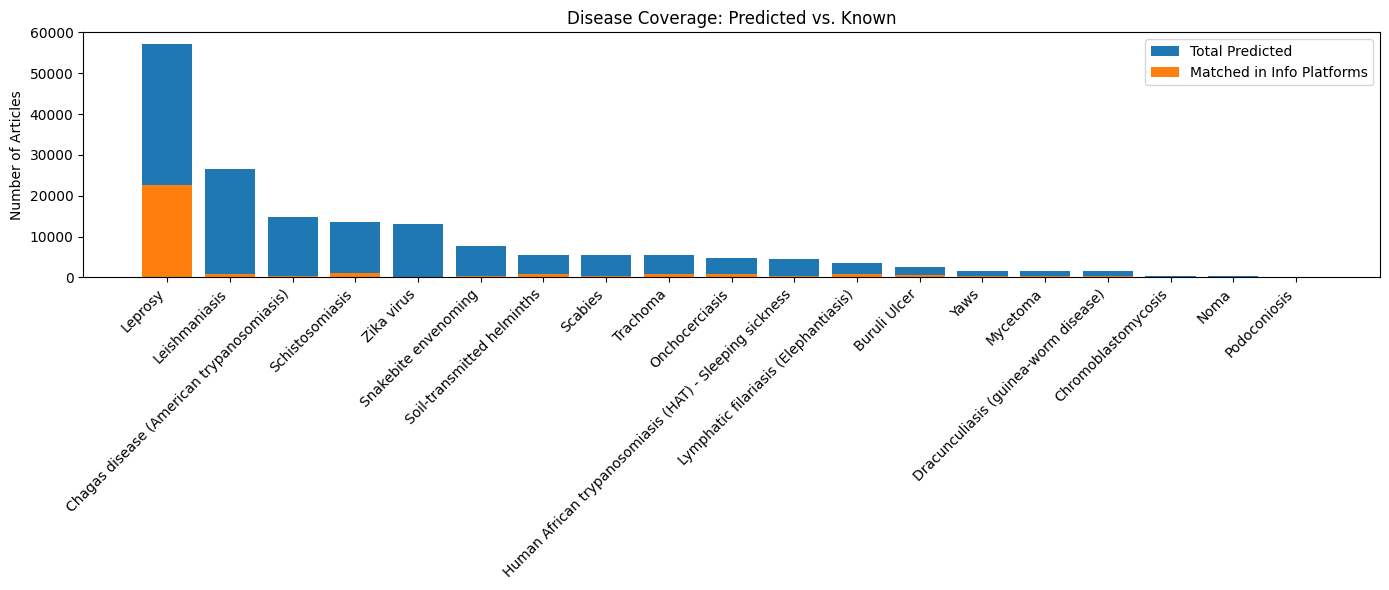

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
x = df_impact["Disease"]
plt.bar(x, df_impact["Total_Predicted"], label="Total Predicted")
plt.bar(x, df_impact["Matched_InfoPlatforms"], label="Matched in Info Platforms")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Articles")
plt.title("Disease Coverage: Predicted vs. Known")
plt.legend()
plt.tight_layout()
plt.show()


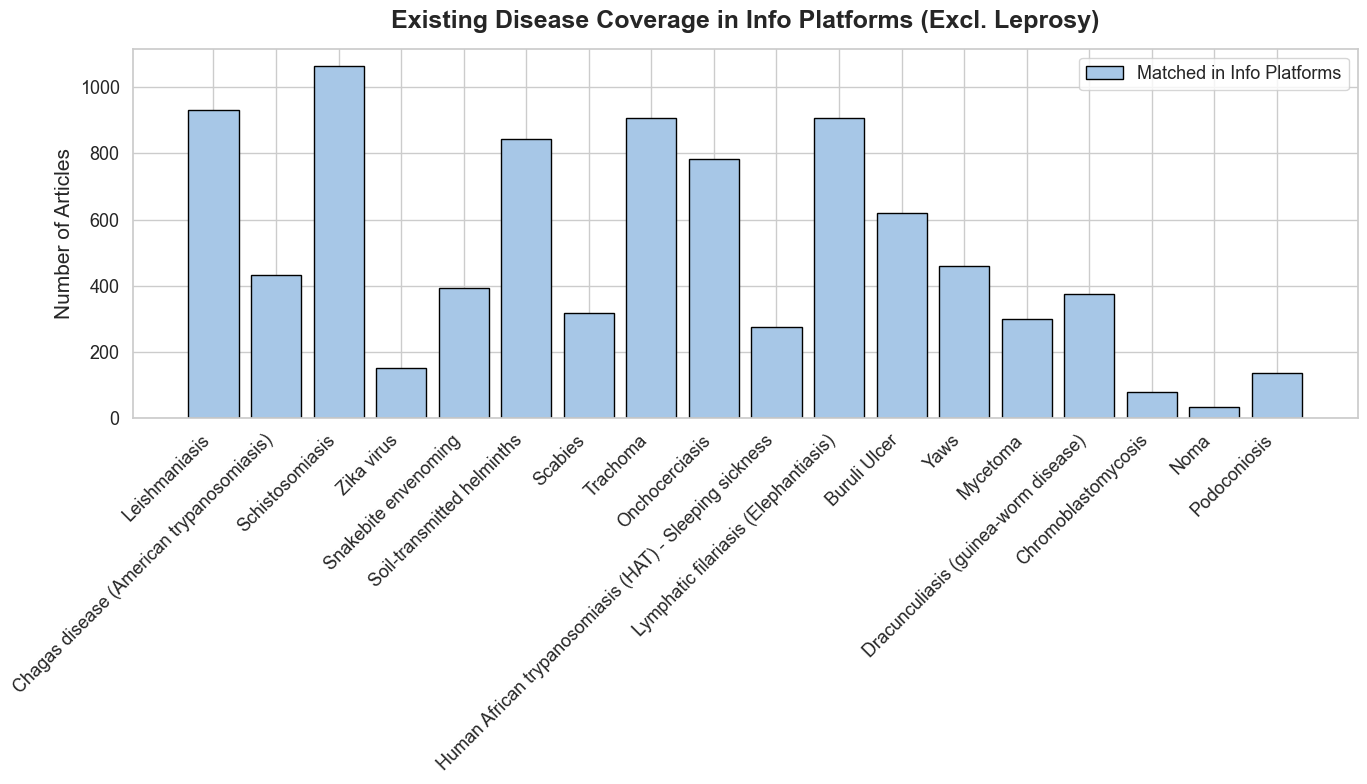

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out leprosy
df_plot = df_impact[df_impact["Disease"].str.lower() != "leprosy"]

# Setup
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))

x = range(len(df_plot))
labels = df_plot["Disease"]

# Bar: Matched only
plt.bar(x, df_plot["Matched_InfoPlatforms"], 
        label="Matched in Info Platforms", 
        color="#a7c7e7", edgecolor="black")

# Axes
plt.xticks(ticks=x, labels=labels, rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.ylabel("Number of Articles", fontsize=15)
plt.title("Existing Disease Coverage in Info Platforms (Excl. Leprosy)", fontsize=18, weight="bold", pad=15)
plt.legend(fontsize=13, title_fontsize=14)
plt.tight_layout()
plt.show()


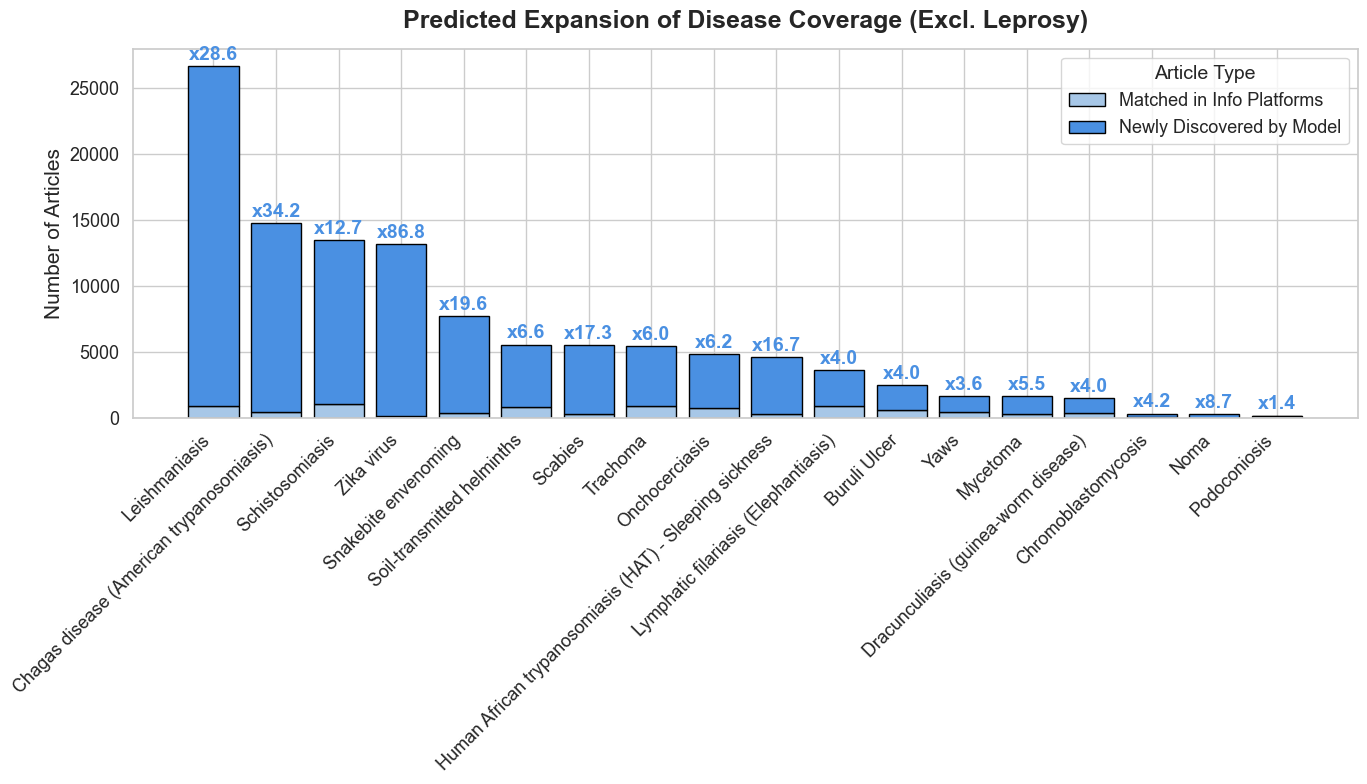

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out Leprosy
df_plot = df_impact[df_impact["Disease"].str.lower() != "leprosy"].copy()
df_plot = df_plot.reset_index(drop=True)  # Ensures clean indexing

# Setup
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))

x = list(range(len(df_plot)))
labels = df_plot["Disease"]

# Plot stacked bars
matched = df_plot["Matched_InfoPlatforms"]
unmatched = df_plot["Unmatched_New"]

plt.bar(x, matched, 
        label="Matched in Info Platforms", 
        color="#a7c7e7", edgecolor="black")

plt.bar(x, unmatched, 
        bottom=matched,
        label="Newly Discovered by Model", 
        color="#4a90e2", edgecolor="black")

# Correctly ordered annotations
for i in x:
    m = matched[i]
    u = unmatched[i]
    if m > 0 and u > 0:
        multiplier = (m + u) / m
        total_height = m + u
        plt.text(i, total_height + 500, 
                 f"x{multiplier:.1f}", 
                 ha='center', fontsize=14, weight='bold', color="#4a90e2")

# Axes
plt.xticks(ticks=x, labels=labels, rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.ylabel("Number of Articles", fontsize=15)
plt.title("Predicted Expansion of Disease Coverage (Excl. Leprosy)", fontsize=18, weight="bold", pad=15)
plt.legend(fontsize=13, title="Article Type", title_fontsize=14)
plt.tight_layout()
plt.show()


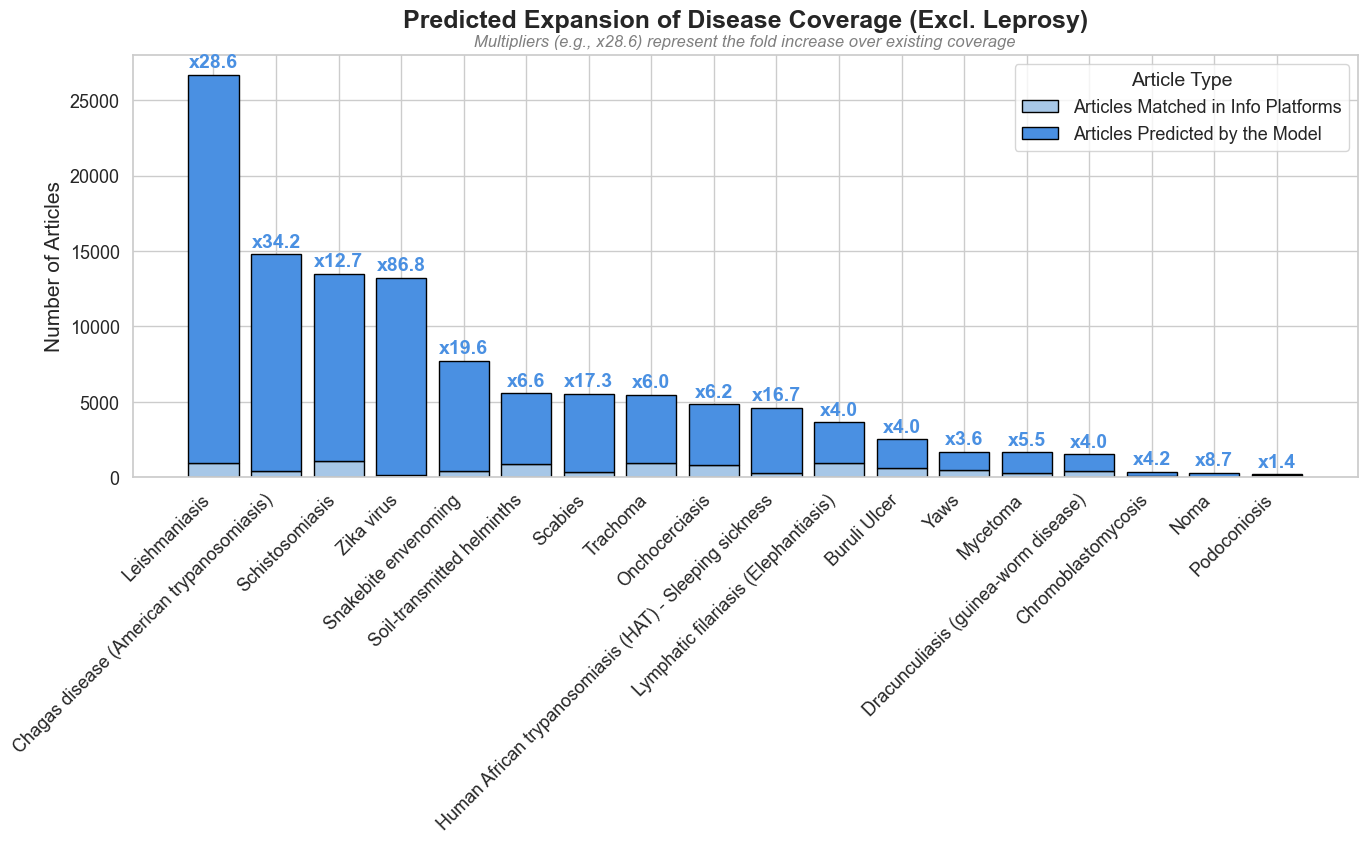

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out Leprosy
df_plot = df_impact[df_impact["Disease"].str.lower() != "leprosy"].copy()
df_plot = df_plot.reset_index(drop=True)  # Ensures clean indexing

# Setup
sns.set(style="whitegrid")
plt.figure(figsize=(14, 9.5))

x = list(range(len(df_plot)))
labels = df_plot["Disease"]

# Plot stacked bars
matched = df_plot["Matched_InfoPlatforms"]
unmatched = df_plot["Unmatched_New"]

plt.bar(x, matched, 
        label="Articles Matched in Info Platforms", 
        color="#a7c7e7", edgecolor="black")

plt.bar(x, unmatched, 
        bottom=matched,
        label="Articles Predicted by the Model", 
        color="#4a90e2", edgecolor="black")

# Annotations
for i in x:
    m = matched[i]
    u = unmatched[i]
    if m > 0 and u > 0:
        multiplier = (m + u) / m
        total_height = m + u
        plt.text(i, total_height + 500, 
                 f"x{multiplier:.1f}", 
                 ha='center', fontsize=14, weight='bold', color="#4a90e2")

# Axes and Titles
plt.xticks(ticks=x, labels=labels, rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.ylabel("Number of Articles", fontsize=15)

plt.title("Predicted Expansion of Disease Coverage (Excl. Leprosy)", 
          fontsize=18, weight="bold", pad = 20)

# Subtitle (manually positioned)
plt.suptitle("                              Multipliers (e.g., x28.6) represent the fold increase over existing coverage", 
             fontsize=12, y=0.86, style="italic", color="gray")

plt.legend(fontsize=13, title="Article Type", title_fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # Adjust for subtitle
plt.show()


In [51]:
import pandas as pd

# Load your prediction and match sets
df_pred = pd.read_csv("Samples/pubmed_svm_class1_diseases.csv")
df_matches = pd.read_csv("Samples/pubmed_predictions_matched_to_InfoPlatforms.csv")

# Get disease label columns
disease_pred_cols = [col for col in df_pred.columns if col.endswith("_pred")]
diseases = [col.replace("_pred", "") for col in disease_pred_cols]

# Build summary table
rows = []
for d in diseases:
    col = f"{d}_pred"
    total = int(df_pred[col].sum())
    matched = int(df_matches[col].sum())
    new = total - matched
    pct_new = round(100 * new / total, 1) if total else 0
    pct_matched = round(100 * matched / total, 1) if total else 0
    growth_factor = round(total / matched, 2) if matched else float('inf')

    rows.append({
        "Disease": d,
        "Total Identified": total,
        "% Newly Predicted (n)": f"{pct_new}% ({new})",
        "% Matched (n)": f"{pct_matched}% ({matched})",
        "Growth Factor": growth_factor
    })

# Create and sort DataFrame
df_summary = pd.DataFrame(rows).sort_values(by="Growth Factor", ascending=False)
df_summary.to_csv("Samples/ntd_nlr_disease_summary.csv", index=False)
print("✅ Saved disease summary to Samples/ntd_nlr_disease_summary.csv")

# Optional: Display top N
print(df_summary.head(10))


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_34392\1973942053.py:4: DtypeWarning: Columns (0,5,6,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pred = pd.read_csv("Samples/pubmed_svm_class1_diseases.csv")


✅ Saved disease summary to Samples/ntd_nlr_disease_summary.csv
                                              Disease  Total Identified  \
18                                         Zika virus             13189   
1           Chagas disease (American trypanosomiasis)             14772   
5                                       Leishmaniasis             26660   
14                               Snakebite envenoming              7724   
12                                            Scabies              5512   
4   Human African trypanosomiasis (HAT) - Sleeping...              4615   
13                                    Schistosomiasis             13483   
9                                                Noma               287   
15                         Soil-transmitted helminths              5549   
10                                     Onchocerciasis              4832   

   % Newly Predicted (n) % Matched (n)  Growth Factor  
18         98.8% (13037)    1.2% (152)          86.77  

In [52]:
df_summary

,Disease,Total Identified,% Newly Predicted (n),% Matched (n),Growth Factor
18,Zika virus,13189,98.8% (13037),1.2% (152),86.77
1,Chagas disease (American trypanosomiasis),14772,97.1% (14340),2.9% (432),34.19
5,Leishmaniasis,26660,96.5% (25728),3.5% (932),28.61
14,Snakebite envenoming,7724,94.9% (7330),5.1% (394),19.60
12,Scabies,5512,94.2% (5193),5.8% (319),17.28
4,Human African trypanosomiasis (HAT) - Sleeping...,4615,94.0% (4339),6.0% (276),16.72
13,Schistosomiasis,13483,92.1% (12420),7.9% (1063),12.68
9,Noma,287,88.5% (254),11.5% (33),8.70
15,Soil-transmitted helminths,5549,84.8% (4706),15.2% (843),6.58
10,Onchocerciasis,4832,83.8% (4049),16.2% (783),6.17


In [24]:
df_summary

,Disease,Total Identified,% Newly Predicted (n),% Matched (n),Growth Factor
18,Zika virus,13189,98.8% (13037),1.2% (152),86.77
1,Chagas disease (American trypanosomiasis),14772,97.1% (14340),2.9% (432),34.19
5,Leishmaniasis,26660,96.5% (25728),3.5% (932),28.61
14,Snakebite envenoming,7724,94.9% (7330),5.1% (394),19.60
12,Scabies,5512,94.2% (5193),5.8% (319),17.28
4,Human African trypanosomiasis (HAT) - Sleeping...,4615,94.0% (4339),6.0% (276),16.72
13,Schistosomiasis,13483,92.1% (12420),7.9% (1063),12.68
9,Noma,287,88.5% (254),11.5% (33),8.70
15,Soil-transmitted helminths,5549,84.8% (4706),15.2% (843),6.58
10,Onchocerciasis,4832,83.8% (4049),16.2% (783),6.17
